# 03C – Model Comparison (Enterprise)

Compare multiple machine learning models using the cleaned bankruptcy dataset and select the best production candidate.

## Business Objective
Evaluate several classification algorithms on the same preprocessed dataset and select the model that provides the best balance of predictive performance and generalization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [2]:
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'

df=pd.read_csv(DATA_PATH)
target='status_label' if 'status_label' in df.columns else 'target'

y=df[target].map({'alive':0,'failed':1}) if not pd.api.types.is_numeric_dtype(df[target]) else df[target]
X=df.drop(columns=[target])
if 'company_name' in X.columns:
    X=X.drop(columns=['company_name'])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

# Subsample the training set so all four models can be compared quickly;
# stratified sampling keeps the class balance representative.
COMPARISON_SAMPLE_SIZE = 20000
if len(X_train) > COMPARISON_SAMPLE_SIZE:
    X_train,_,y_train,_ = train_test_split(
        X_train, y_train,
        train_size=COMPARISON_SAMPLE_SIZE,
        stratify=y_train,
        random_state=42
    )


In [3]:
models={
'Logistic Regression':LogisticRegression(max_iter=1000),
'Decision Tree':DecisionTreeClassifier(random_state=42),
'Random Forest':RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced',n_jobs=1),
'Gradient Boosting':GradientBoostingClassifier(random_state=42,n_estimators=60,max_depth=3)
}

results=[]

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    prob=model.predict_proba(X_test)[:,1]
    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test,pred),
        'F1 Score':f1_score(y_test,pred),
        'ROC-AUC':roc_auc_score(y_test,prob)
    })

comparison=pd.DataFrame(results).sort_values('ROC-AUC',ascending=False)
comparison.to_csv('model_comparison_results.csv',index=False)
comparison


,Model,Accuracy,F1 Score,ROC-AUC
2,Random Forest,0.934422,0.026415,0.832724
3,Gradient Boosting,0.933469,0.036799,0.762762
0,Logistic Regression,0.933787,0.018832,0.658678
1,Decision Tree,0.890132,0.220117,0.585245


Best Model: Random Forest


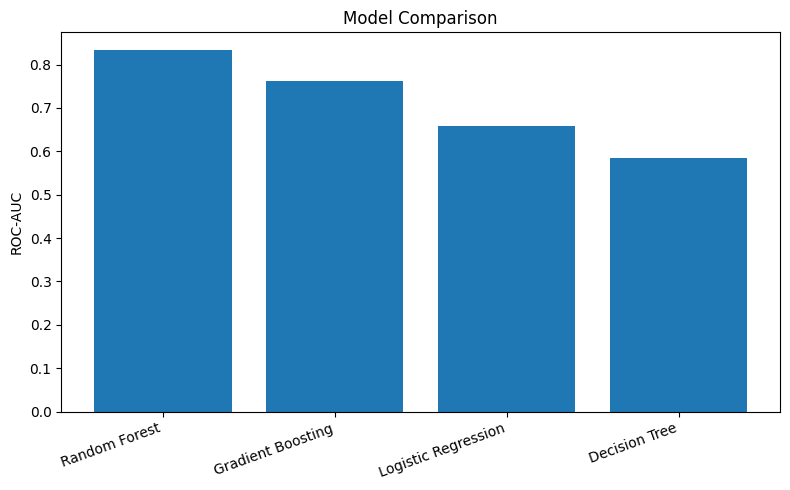

In [4]:
best_model=comparison.iloc[0]['Model']
print('Best Model:',best_model)

plt.figure(figsize=(8,5))
plt.bar(comparison['Model'],comparison['ROC-AUC'])
plt.xticks(rotation=20,ha='right')
plt.ylabel('ROC-AUC')
plt.title('Model Comparison')
plt.tight_layout()
plt.savefig('model_comparison.png',dpi=300)
plt.show()


## Deliverables

- `model_comparison_results.csv`
- `model_comparison.png`

The selected best-performing model should be promoted to production and used in subsequent explainability, validation, and deployment phases.